# Fine-tuning de ViT-B/16 en CIFAR-10

Este notebook hace fine-tuning del **Vision Transformer Base con parches de 16x16** (`ViT-B/16`), el modelo canonico del paper *An Image is Worth 16x16 Words* (Dosovitskiy et al., 2020), sobre **CIFAR-10**.

Usamos el checkpoint pre-entrenado en **ImageNet-21k** y luego en **ImageNet-1k** (provisto por Google y disponible en `timm`).

## Pasos
1. Instalar e importar dependencias.
2. Cargar `ViT-B/16` pre-entrenado y **explicar su arquitectura**.
3. Adaptar la cabeza de clasificacion a 10 clases.
4. Preparar CIFAR-10 con resize a 224x224 y normalizacion ImageNet.
5. Fine-tune con AdamW + cosine schedule.
6. Evaluar y mostrar predicciones.

## 1) Dependencias

Necesitamos `torch`, `torchvision` y `timm` (que tiene los pesos oficiales de ViT).

In [19]:
# Si hace falta, descomenta:
# pip install -q timm torch torchvision matplotlib

In [20]:
import os
import math
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms

import timm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('timm version:', timm.__version__)

Device: cuda
timm version: 1.0.24


## 2) Cargar ViT-B/16 pre-entrenado

Usamos la variante `vit_base_patch16_224.augreg_in21k_ft_in1k`:

- `vit_base` -> tamano **Base** del paper.
- `patch16` -> parches de **16x16**.
- `224` -> resolucion de entrada.
- `augreg_in21k_ft_in1k` -> entrenado en **ImageNet-21k** y luego fine-tuned en **ImageNet-1k** (Steiner et al., "How to train your ViT").

In [21]:
model = timm.create_model(
    'vit_base_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=10,  # adaptamos la cabeza para CIFAR-10
)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros totales:     {n_params/1e6:.2f} M')
print(f'Parametros entrenables: {n_trainable/1e6:.2f} M')

Parametros totales:     85.81 M
Parametros entrenables: 85.81 M


### Como se usa `timm` para hacer fine-tuning

[`timm`](https://github.com/huggingface/pytorch-image-models) (PyTorch Image Models) es la libreria de referencia para modelos de vision pre-entrenados. Trae cientos de checkpoints listos (ViT, DeiT, Swin, ConvNeXt, EVA, BEiT, etc.) y se integra directo con PyTorch. La receta de fine-tuning son 4 pasos:

**1. Crear el modelo y reemplazar la cabeza automaticamente.**

```python
model = timm.create_model('vit_base_patch16_224.augreg_in21k_ft_in1k',
                          pretrained=True,
                          num_classes=10)
```

- `pretrained=True` descarga los pesos.
- `num_classes=10` **reemplaza la capa final** (`model.head`) por una `Linear(768 -> 10)` inicializada de forma aleatoria. El resto del backbone conserva sus pesos pre-entrenados.
- Si pones `num_classes=0` te da el modelo sin cabeza (solo el extractor de features), util para embeddings.

**2. Usar las transformaciones correctas.**

Cada checkpoint tiene su propia normalizacion y resolucion. `timm` te las da listas:

```python
data_cfg = timm.data.resolve_model_data_config(model)
train_tf = timm.data.create_transform(**data_cfg, is_training=True)
test_tf  = timm.data.create_transform(**data_cfg, is_training=False)
```

En este notebook lo escribimos a mano (Resize 224 + normalizacion ImageNet) para que se vea claro, pero en produccion se usa `create_transform`.

**3. Elegir que congelar.**

Tres estrategias comunes:

| Estrategia | Que se entrena | Cuando usarla |
|---|---|---|
| **Linear probing** | Solo `model.head` | Dataset chico, GPU limitada |
| **Full fine-tuning** | Todo el modelo | Dataset mediano/grande (CIFAR-10 entra aqui) |
| **Last-N blocks** | `head` + ultimos N bloques | Compromiso entre los dos |

Para *linear probing* se hace asi:

```python
for p in model.parameters():
    p.requires_grad = False
for p in model.head.parameters():
    p.requires_grad = True
```

Aqui hacemos **full fine-tuning** porque CIFAR-10 tiene 50k imagenes y vale la pena ajustar todo.

**4. Optimizador con LR pequeno + scheduler.**

Como los pesos ya son buenos, el LR debe ser **bajo** (1e-5 a 5e-5 para ViT con AdamW) y conviene `cosine schedule` con un warmup corto. `timm` tambien ofrece `timm.optim.create_optimizer_v2` y `timm.scheduler`, pero aqui usamos los de PyTorch para mantenerlo simple.

Con esto, el resto del codigo (loss, training loop, evaluacion) es PyTorch puro.

### Arquitectura de ViT-B/16 (explicacion)

ViT-B/16 sigue exactamente el diseno del paper. Para una entrada de **224x224x3**:

**Hiperparametros del modelo Base**

| Componente | Valor |
|---|---|
| Tamano de parche `P` | 16 |
| Numero de parches `N` | (224/16)^2 = **196** |
| Dimension del embedding `D` | **768** |
| Capas Transformer `L` | **12** |
| Cabezas de atencion por capa | **12** (cada una de 64 dim) |
| Dim oculta del MLP | **3072** (4 * D) |
| Total de parametros | **~86 M** |

**Flujo de datos**

1. **Patch Embedding** (`patch_embed`): una `Conv2d` de kernel 16, stride 16 que parte la imagen en 196 parches y los proyecta a 768. Equivale a aplanar cada parche y pasarlo por una capa lineal (truco eficiente).
2. **[CLS] token + positional embedding** (`cls_token`, `pos_embed`): se antepone un token aprendible y se suma un embedding posicional aprendido. La secuencia queda de longitud **197 = 196 + 1**.
3. **Encoder Transformer** (`blocks`): 12 bloques apilados. Cada bloque es:
   - LayerNorm -> Multi-Head Self-Attention (12 heads) -> residual.
   - LayerNorm -> MLP (2 capas, GELU, hidden=3072) -> residual.
   - **Pre-norm**: la normalizacion va antes de cada subcapa (no despues, como en el Transformer original).
4. **Norm final** (`norm`): LayerNorm sobre la secuencia.
5. **Cabeza de clasificacion** (`head`): se toma el vector del **token `[CLS]`** (posicion 0) y se pasa por una `Linear(768 -> num_classes)`.

Esquematicamente:

$$
\text{img} \xrightarrow{\text{Conv 16x16}} 196\text{ tokens} \xrightarrow{+\text{[CLS]}+E_{pos}} 197 \text{ tokens}
\xrightarrow{12 \times \text{Block}} \text{LN} \xrightarrow{[CLS]} \text{Linear} \to \text{logits}
$$

Vamos a inspeccionar el modelo real para confirmar estas piezas:

In [22]:
# Modulos top-level
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f'{name:20s} | {type(module).__name__:30s} | {n/1e6:7.2f} M params')

patch_embed          | PatchEmbed                     |    0.59 M params
pos_drop             | Dropout                        |    0.00 M params
patch_drop           | Identity                       |    0.00 M params
norm_pre             | Identity                       |    0.00 M params
blocks               | Sequential                     |   85.05 M params
norm                 | LayerNorm                      |    0.00 M params
fc_norm              | Identity                       |    0.00 M params
head_drop            | Dropout                        |    0.00 M params
head                 | Linear                         |    0.01 M params


In [23]:
# Detalles clave de las piezas principales
print('--- Patch embedding ---')
print(model.patch_embed)
print('cls_token shape :', tuple(model.cls_token.shape))
print('pos_embed shape :', tuple(model.pos_embed.shape), '  (debe ser (1, 197, 768))')
print()
print('--- Numero de bloques Transformer ---')
print(f'len(model.blocks) = {len(model.blocks)}  (esperado 12)')
print()
print('--- Un bloque Transformer ---')
print(model.blocks[0])
print()
print('--- Cabeza de clasificacion ---')
print(model.head)

--- Patch embedding ---
PatchEmbed(
  (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (norm): Identity()
)
cls_token shape : (1, 1, 768)
pos_embed shape : (1, 197, 768)   (debe ser (1, 197, 768))

--- Numero de bloques Transformer ---
len(model.blocks) = 12  (esperado 12)

--- Un bloque Transformer ---
Block(
  (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (attn): Attention(
    (qkv): Linear(in_features=768, out_features=2304, bias=True)
    (q_norm): Identity()
    (k_norm): Identity()
    (attn_drop): Dropout(p=0.0, inplace=False)
    (norm): Identity()
    (proj): Linear(in_features=768, out_features=768, bias=True)
    (proj_drop): Dropout(p=0.0, inplace=False)
  )
  (ls1): Identity()
  (drop_path1): Identity()
  (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (mlp): Mlp(
    (fc1): Linear(in_features=768, out_features=3072, bias=True)
    (act): GELU(approximate='none')
    (drop1): Dropout(p=0.0, inplace=False)
    (norm): Iden

In [24]:
# Sanity check: una imagen aleatoria atraviesa el modelo y produce logits (1, 10)
model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224, device=device)
    logits = model(dummy)
print('logits shape:', tuple(logits.shape))

logits shape: (1, 10)


## 3) Datos: CIFAR-10 con split train / val / test

CIFAR-10 trae oficialmente 50 000 imagenes de train y 10 000 de test. Para no usar el conjunto de test durante el ajuste de hiperparametros lo dividimos asi:

| Split | Tamano | Uso |
|---|---|---|
| **train** | 45 000 | Entrenar pesos |
| **val**   | 5 000  | Monitorear cada epoca, decidir early stopping / ajustes |
| **test**  | 10 000 | Evaluacion FINAL + matriz de confusion |

Detalles importantes:
- CIFAR-10 viene en **32x32**, pero ViT-B/16 espera **224x224**. Por eso hacemos `Resize(224)`.
- Usamos la **normalizacion de ImageNet** (no la de CIFAR), ya que el backbone fue pre-entrenado con esa estadistica.
- Solo en **train** aplicamos augmentation; en val y test usamos el pipeline limpio.

In [25]:
from torch.utils.data import Subset

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomCrop(224, padding=16),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

data_dir = './data'

# Dos copias del set de "train" oficial: una con augmentation (para train) y otra sin (para val).
trainval_aug   = torchvision.datasets.CIFAR10(root=data_dir, train=True,  download=True, transform=train_tf)
trainval_clean = torchvision.datasets.CIFAR10(root=data_dir, train=True,  download=True, transform=eval_tf)
test_set       = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=eval_tf)

# Split reproducible 45k / 5k
N = len(trainval_aug)  # 50000
VAL_SIZE = 5000
g = torch.Generator().manual_seed(42)
perm = torch.randperm(N, generator=g).tolist()
val_idx   = perm[:VAL_SIZE]
train_idx = perm[VAL_SIZE:]

train_set = Subset(trainval_aug,   train_idx)
val_set   = Subset(trainval_clean, val_idx)

BATCH = 64 if device.type == 'cuda' else 16
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = trainval_aug.classes
print('Clases:', CLASSES)
print(f'Train: {len(train_set)}  Val: {len(val_set)}  Test: {len(test_set)}  Batch: {BATCH}')

Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 45000  Val: 5000  Test: 10000  Batch: 64


## 4) Loop de entrenamiento

Configuracion (consejos de `timm` y del paper para fine-tuning):

- Optimizador: **AdamW**, `lr=3e-5`, `weight_decay=0.05`.
- Schedule: **cosine** con warmup corto (10% de los steps).
- Loss: cross-entropy con `label_smoothing=0.1`.
- Mixed precision con la API moderna `torch.amp.autocast('cuda')` / `torch.amp.GradScaler('cuda')` (la antigua `torch.cuda.amp.*` esta deprecada desde PyTorch 2.4).
- Cada epoca evaluamos en **val** (no en test).

In [26]:
EPOCHS = 10
LR = 3e-5
WD = 0.05
WARMUP_FRAC = 0.1

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

total_steps = EPOCHS * len(train_loader)
warmup_steps = int(total_steps * WARMUP_FRAC)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# API moderna: torch.amp en lugar de torch.cuda.amp (deprecado desde PyTorch 2.4)
use_amp = (device.type == 'cuda')
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

print(f'Total steps: {total_steps}  Warmup: {warmup_steps}  AMP: {use_amp}')

Total steps: 7040  Warmup: 704  AMP: True


In [27]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    loss_sum = 0.0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)
        loss_sum += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return loss_sum / total, correct / total

In [28]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    running_loss = 0.0
    running_correct = 0
    seen = 0
    for i, (x, y) in enumerate(train_loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item() * x.size(0)
        running_correct += (logits.argmax(dim=1) == y).sum().item()
        seen += x.size(0)

        if (i + 1) % 50 == 0:
            print(f'  epoch {epoch}  step {i+1}/{len(train_loader)}  loss {running_loss/seen:.4f}  lr {scheduler.get_last_lr()[0]:.2e}')

    train_loss = running_loss / seen
    train_acc  = running_correct / seen
    val_loss, val_acc = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch}/{EPOCHS}  '
          f'train_loss {train_loss:.4f}  train_acc {train_acc*100:.2f}%  '
          f'val_loss {val_loss:.4f}  val_acc {val_acc*100:.2f}%  '
          f'({time.time()-t0:.1f}s)')

  epoch 1  step 50/704  loss 2.9032  lr 2.13e-06
  epoch 1  step 100/704  loss 2.1110  lr 4.26e-06
  epoch 1  step 150/704  loss 1.6476  lr 6.39e-06
  epoch 1  step 200/704  loss 1.3941  lr 8.52e-06
  epoch 1  step 250/704  loss 1.2335  lr 1.07e-05
  epoch 1  step 300/704  loss 1.1247  lr 1.28e-05
  epoch 1  step 350/704  loss 1.0460  lr 1.49e-05
  epoch 1  step 400/704  loss 0.9865  lr 1.70e-05
  epoch 1  step 450/704  loss 0.9411  lr 1.92e-05
  epoch 1  step 500/704  loss 0.9039  lr 2.13e-05
  epoch 1  step 550/704  loss 0.8718  lr 2.34e-05
  epoch 1  step 600/704  loss 0.8457  lr 2.56e-05
  epoch 1  step 650/704  loss 0.8246  lr 2.77e-05
  epoch 1  step 700/704  loss 0.8063  lr 2.98e-05
Epoch 1/10  train_loss 0.8053  train_acc 89.58%  val_loss 0.5743  val_acc 98.24%  (88.1s)
  epoch 2  step 50/704  loss 0.5524  lr 3.00e-05
  epoch 2  step 100/704  loss 0.5496  lr 3.00e-05
  epoch 2  step 150/704  loss 0.5478  lr 3.00e-05
  epoch 2  step 200/704  loss 0.5470  lr 2.99e-05
  epoch 2  s

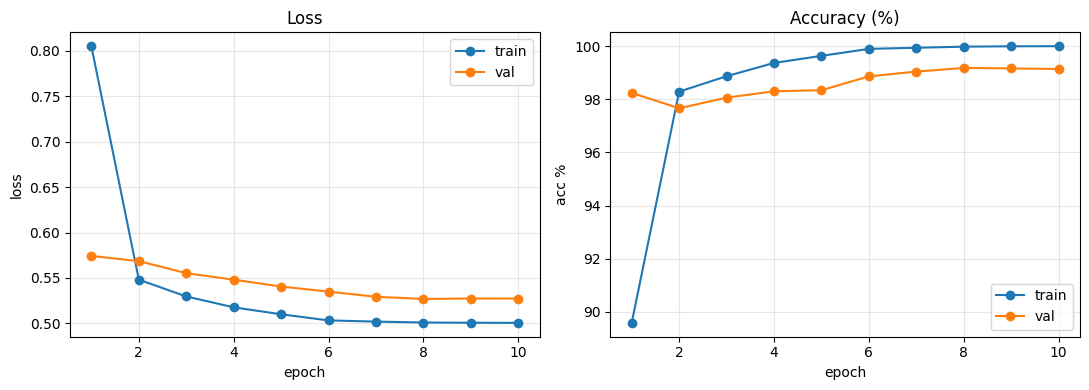

In [29]:
epochs_x = range(1, len(history['train_loss']) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(epochs_x, history['train_loss'], marker='o', label='train')
ax[0].plot(epochs_x, history['val_loss'],   marker='o', label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(epochs_x, [a*100 for a in history['train_acc']], marker='o', label='train')
ax[1].plot(epochs_x, [a*100 for a in history['val_acc']],   marker='o', label='val')
ax[1].set_title('Accuracy (%)'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('acc %')
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 5) Evaluacion final en test + matriz de confusion

Hasta aqui solo usamos **val** para monitorear. Ahora corremos el modelo final una sola vez sobre **test** y graficamos la matriz de confusion para ver donde se equivoca.

In [30]:
from sklearn.metrics import confusion_matrix, classification_report

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    all_pred, all_true = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = model(x)
        all_pred.append(logits.argmax(dim=1).cpu())
        all_true.append(y)
    return torch.cat(all_pred).numpy(), torch.cat(all_true).numpy()

y_pred, y_true = predict_all(model, test_loader)
test_acc = (y_pred == y_true).mean()
print(f'Test accuracy: {test_acc*100:.2f}%')
print()
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

Test accuracy: 98.80%

              precision    recall  f1-score   support

    airplane     0.9960    0.9960    0.9960      1000
  automobile     0.9842    0.9950    0.9896      1000
        bird     0.9990    0.9940    0.9965      1000
         cat     0.9643    0.9730    0.9686      1000
        deer     0.9871    0.9930    0.9900      1000
         dog     0.9707    0.9620    0.9663      1000
        frog     0.9950    0.9960    0.9955      1000
       horse     0.9960    0.9910    0.9935      1000
        ship     0.9940    0.9970    0.9955      1000
       truck     0.9939    0.9830    0.9884      1000

    accuracy                         0.9880     10000
   macro avg     0.9880    0.9880    0.9880     10000
weighted avg     0.9880    0.9880    0.9880     10000



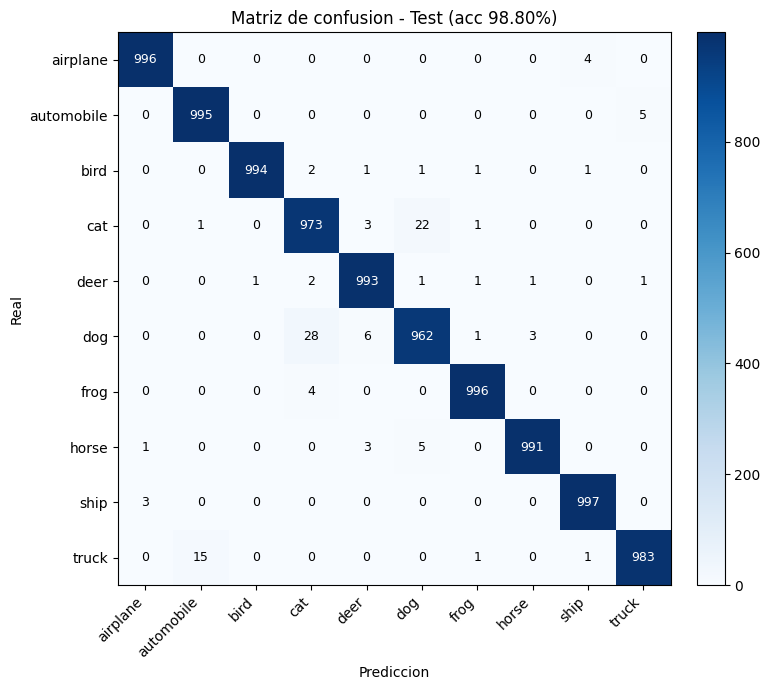

In [31]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusion - Test (acc {test_acc*100:.2f}%)')

# Anotaciones
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 6) Predicciones de ejemplo (test)

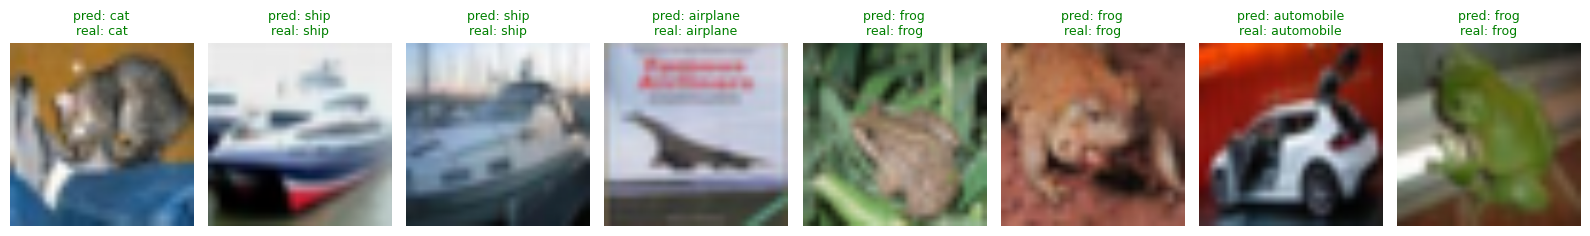

In [32]:
def desnormalizar(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t.cpu() * std + mean).clamp(0, 1)

model.eval()
x, y = next(iter(test_loader))
x = x.to(device)
with torch.no_grad(), torch.amp.autocast('cuda', enabled=use_amp):
    pred = model(x).argmax(dim=1).cpu()

n = 8
fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5))
for i in range(n):
    img = desnormalizar(x[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    color = 'green' if pred[i].item() == y[i].item() else 'red'
    axes[i].set_title(f'pred: {CLASSES[pred[i]]}\nreal: {CLASSES[y[i]]}', fontsize=9, color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()